In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.dates import DayLocator, DateFormatter

DATE_COL = 'Дата продажи'
DATETIME_COL = 'Дата время чека'
EVENT_COL = 'Вид события по кассе'
BAKERY_COL = 'Касса.Торговая точка'
PRODUCT_COL = 'Номенклатура'
QTY_COL = 'Кол-во'
SALES_EVENT = 'Продажа'


In [2]:
df = pd.read_csv('C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/raw/sales_hrs_all.csv')

In [8]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", dayfirst=True)
df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors="coerce", dayfirst=True)

In [9]:
df_147 = df[(df['Касса.Торговая точка'] == 'Проспект Победы 147 Казань') & (df['Номенклатура'] == 'Вак-бэлиш')]

In [5]:
df_147

,Дата продажи,Дата время чека,Вид события по кассе,Касса.Торговая точка,Категория,Номенклатура,Свежесть,Цена,Кол-во
26486,02.01.2026,02.01.2026 13:16:48,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,2.0
50216,02.01.2026,02.01.2026 17:12:33,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0
50322,02.01.2026,02.01.2026 17:13:48,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0
50774,02.01.2026,02.01.2026 17:19:38,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0
53841,02.01.2026,02.01.2026 18:02:52,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0
...,...,...,...,...,...,...,...,...,...
29771190,30.09.2025,30.09.2025 8:04:22,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Вчерашний,26.0,3.0
29773746,30.09.2025,30.09.2025 8:16:19,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Вчерашний,26.0,2.0
29850163,30.09.2025,30.09.2025 14:32:03,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0
29855533,30.09.2025,30.09.2025 15:02:43,Продажа,Проспект Победы 147 Казань,Выпечка сытная,Вак-бэлиш,Свежий,52.0,1.0


In [10]:
df_147["hour"] = df_147[DATETIME_COL].dt.hour

C:\Users\dns\AppData\Local\Temp\ipykernel_16652\595840263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_147["hour"] = df_147[DATETIME_COL].dt.hour


In [11]:
df["hour"] = df[DATETIME_COL].dt.hour

In [12]:
dff = df_147[df_147["hour"] == 19].groupby(df['Дата продажи'])['Кол-во'].sum()

In [13]:
len(dff)

56

In [ ]:
print(df_147[df_147["hour"] == 19].to_string())

         Дата продажи     Дата время чека Вид события по кассе        Касса.Торговая точка       Категория Номенклатура Свежесть  Цена  Кол-во  hour
132662     2026-01-03 2026-01-03 19:42:41              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
2224465    2026-01-22 2026-01-22 19:06:15              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     5.0    19
5094628    2026-02-15 2026-02-15 19:33:10              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
6693185    2026-02-28 2026-02-28 19:30:51              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
6907161    2026-03-10 2026-03-10 19:05:51              Продажа  Проспект Победы 147 Казань  Выпечка сытная    Вак-бэлиш   Свежий  52.0     1.0    19
7321937    2026-03-13 2026-03-13 19:30:34              Продажа  Проспект Победы 147 Казань  Выпечка сытная

In [14]:
print(f'для последней продажи c 19 по 20 доля от всех продаж {len(df_147[df_147["hour"] == 19].groupby(df['Дата продажи']))/len(df_147.groupby(df['Дата продажи']))}')
print(f'для последней продажи c 19 по 20 всего таких дней {len(df_147[df_147["hour"] == 19].groupby(df['Дата продажи']))}')
print('\n')
print(f'для последней продажи с 20 по 21 доля от всех продаж {len(df_147[df_147["hour"] == 20].groupby(df['Дата продажи']))/len(df_147.groupby(df['Дата продажи']))}')
print(f'для последней продажи с 20 по 21 всего таких дней {len(df_147[df_147["hour"] == 20].groupby(df['Дата продажи']))}')
print(f'всего дней {len(df_147.groupby(df['Дата продажи']))}')

для последней продажи c 19 по 20 доля от всех продаж 0.2413793103448276
для последней продажи c 19 по 20 всего таких дней 56


для последней продажи с 20 по 21 доля от всех продаж 0.16810344827586207
для последней продажи с 20 по 21 всего таких дней 39
всего дней 232


In [15]:
import numpy as np

In [16]:
np.sort(df_147["hour"].unique())

array([ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22],
      dtype=int32)

In [ ]:
d

In [17]:
for h in np.sort(df_147["hour"].unique()):
    print(f'час = {h} количество дней с продажами в этот час = {len(df_147[df_147["hour"] == h].groupby(df['Дата продажи']))}')

час = 6 количество дней с продажами в этот час = 10
час = 7 количество дней с продажами в этот час = 119
час = 8 количество дней с продажами в этот час = 113
час = 9 количество дней с продажами в этот час = 116
час = 10 количество дней с продажами в этот час = 71
час = 11 количество дней с продажами в этот час = 92
час = 12 количество дней с продажами в этот час = 103
час = 13 количество дней с продажами в этот час = 72
час = 14 количество дней с продажами в этот час = 68
час = 15 количество дней с продажами в этот час = 65
час = 16 количество дней с продажами в этот час = 54
час = 17 количество дней с продажами в этот час = 59
час = 18 количество дней с продажами в этот час = 59
час = 19 количество дней с продажами в этот час = 56
час = 20 количество дней с продажами в этот час = 39
час = 22 количество дней с продажами в этот час = 1


In [20]:
df_147_pivot = (
    df_147
    .groupby([DATE_COL, "hour"], as_index=True)[QTY_COL]
    .sum()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

df_147_pivot = df_147_pivot.drop(columns=[6, 22], axis=0)

In [21]:
df_147_pivot

hour,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Дата продажи,,,,,,,,,,,,,,
2025-08-01,0.0,0.0,0.0,0.0,0.0,6.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0
2025-08-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2025-08-04,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2025-08-05,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0
2025-08-06,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1.0,0.0,3.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-29,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2026-03-30,2.0,2.0,4.0,0.0,0.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-31,2.0,0.0,2.0,0.0,1.0,2.0,1.0,3.0,2.0,2.0,0.0,0.0,3.0,0.0


In [22]:
import pandas as pd
import numpy as np

def create_stockout_mask(df_pivot, full_bakery_data):
    """
    df_pivot: твоя матрица по конкретному товару (147)
    full_bakery_data: исходный df со ВСЕМИ чеками пекарни
    """
    # 1. Создаем маску общего трафика пекарни (были ли вообще люди в этот час)
    bakery_traffic = (
        full_bakery_data
        .groupby([DATE_COL, "hour"])
        .size()
        .unstack(fill_value=0)
        .reindex_like(df_pivot) # приводим к той же размерности
    )
    has_traffic = bakery_traffic > 0

    # 2. Проверяем наличие продаж в соседние часы (скользящее окно)
    # Считаем сумму продаж в окне из 3 часов (предыдущий, текущий, следующий)
    # Если сумма > 0, но в текущем 0 — это подозрительно
    rolling_sum = df_pivot.rolling(window=3, center=True, axis=1).sum().fillna(0)
    
    # 3. Формируем итоговую маску подозрительных нулей
    # Условия: 
    # - В этот час продаж конкретного товара 0
    # - В этот час в пекарне в принципе были продажи (был трафик)
    # - В соседние часы этот товар покупали (спрос существует)
    is_suspected = (df_pivot == 0) & has_traffic & (rolling_sum > 0)
    
    return is_suspected.astype(int)

# Применяем
stockout_mask = create_stockout_mask(df_147_pivot, df) # df - это твой исходный датафрейм со всеми чеками

C:\Users\dns\AppData\Local\Temp\ipykernel_16652\2666266808.py:22: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  rolling_sum = df_pivot.rolling(window=3, center=True, axis=1).sum().fillna(0)


In [23]:
df_147_pivot

hour,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Дата продажи,,,,,,,,,,,,,,
2025-08-01,0.0,0.0,0.0,0.0,0.0,6.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0
2025-08-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2025-08-04,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2025-08-05,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0
2025-08-06,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1.0,0.0,3.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-29,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2026-03-30,2.0,2.0,4.0,0.0,0.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-31,2.0,0.0,2.0,0.0,1.0,2.0,1.0,3.0,2.0,2.0,0.0,0.0,3.0,0.0


In [24]:
stockout_mask

hour,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Дата продажи,,,,,,,,,,,,,,
2025-08-01,0,0,0,0,1,0,0,1,0,1,1,0,0,0
2025-08-03,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2025-08-04,0,1,0,1,0,0,0,0,0,0,1,0,1,0
2025-08-05,0,1,0,0,0,0,0,0,0,1,0,1,0,0
2025-08-06,0,0,0,0,1,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-29,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2026-03-30,0,0,0,1,1,0,0,0,1,0,0,0,0,0
2026-03-31,0,1,0,1,0,0,0,0,0,0,1,1,0,0


In [25]:
def create_advanced_stockout_mask(df_pivot, full_bakery_data, threshold=0.3):
    # 1. Считаем медианные продажи для каждого часа по всем дням
    # Это наш "эталон" того, как обычно идут дела
    hourly_median = df_pivot[df_pivot > 0].median(axis=0)
    
    # 2. Маска общего трафика (как и раньше)
    bakery_traffic = (
        full_bakery_data
        .groupby(['Дата продажи', "hour"])
        .size()
        .unstack(fill_value=0)
        .reindex_like(df_pivot)
    )
    
    # 3. Условие "Провала": продажи меньше X% от типичных для этого часа
    is_low_sales = df_pivot < (hourly_median * threshold)
    print(f"Hourly median sales:\n{hourly_median}")
    # 4. Условие "Живой пекарни": в пекарне в этот час были люди (общий трафик выше медианы)
    # Это защищает нас от того, чтобы не пометить "плохой день для всех" как стокаут одного товара
    median_traffic = bakery_traffic.median(axis=0)
    has_normal_traffic = bakery_traffic >= (median_traffic * 0.5)

    # Итоговая маска: 
    # (Продажи подозрительно низкие) И (Люди в магазине были) И (В соседние часы товар был)
    rolling_sum = df_pivot.rolling(window=3, center=True, axis=1).sum().fillna(0)
    
    advanced_mask = is_low_sales & has_normal_traffic & (rolling_sum > 0)
    
    return advanced_mask.astype(int)

# Запускаем с порогом 30%
advanced_stockout_mask = create_advanced_stockout_mask(df_147_pivot, df, threshold=0.3)

Hourly median sales:
hour
7     2.0
8     2.0
9     2.0
10    2.0
11    2.0
12    2.0
13    1.0
14    2.0
15    2.0
16    2.0
17    2.0
18    1.0
19    1.5
20    2.0
dtype: float64


C:\Users\dns\AppData\Local\Temp\ipykernel_16652\325066391.py:25: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  rolling_sum = df_pivot.rolling(window=3, center=True, axis=1).sum().fillna(0)


In [26]:
df_147_pivot

hour,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Дата продажи,,,,,,,,,,,,,,
2025-08-01,0.0,0.0,0.0,0.0,0.0,6.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0
2025-08-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2025-08-04,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2025-08-05,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0
2025-08-06,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1.0,0.0,3.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-29,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2026-03-30,2.0,2.0,4.0,0.0,0.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-31,2.0,0.0,2.0,0.0,1.0,2.0,1.0,3.0,2.0,2.0,0.0,0.0,3.0,0.0


In [27]:
advanced_stockout_mask

hour,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Дата продажи,,,,,,,,,,,,,,
2025-08-01,0,0,0,0,1,0,0,1,0,1,1,0,0,0
2025-08-03,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2025-08-04,0,1,0,1,0,0,0,0,0,0,1,0,1,0
2025-08-05,0,1,0,0,0,0,0,0,0,1,0,1,0,0
2025-08-06,0,0,0,0,1,0,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-29,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2026-03-30,0,0,0,1,1,0,0,0,1,0,0,0,0,0
2026-03-31,0,1,0,1,0,0,0,0,0,0,1,1,0,0


In [29]:
!pip install pymc

  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/562.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/562.9 kB ? eta -:--:--
   ---------------------------------------- 562.9/562.9 kB 3.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------- -------- 1.3/1.7 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.2 MB/s  0:00:00
   ------------


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
with pm.Model() as model:
    # Глобальные параметры спроса для этого товара
    mu_global = pm.Exponential("mu_global", 1.0)
    
    # Интенсивность для каждого часа (теперь они связаны через mu_global)
    lam = pm.Exponential("lam", mu_global, shape=observed_values.shape[1])
    
    dist = pm.Poisson.dist(mu=lam[None, :])
    
    y_obs = pm.Censored(
        "y_obs",
        dist,
        lower=None,
        upper=np.where(censoring_mask, observed_values, np.inf),
        observed=observed_values
    )
    
    # ВМЕСТО pm.sample используем быстрый метод приближения
    approx = pm.fit(n=30000, method="advi") # 30к итераций пройдут за 1-2 минуты
    trace = approx.sample(1000)

c:\Users\dns\Desktop\Projects\demand-forecasting-model\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Interrupted at 520 [1%]: Average Loss = 4,495.9


In [33]:
trace

Inference data with groups:
	> posterior
	> observed_data

In [35]:
import pymc as pm
import numpy as np

# 1. Сделаем маску строже (только явные провалы)
# Оставляем стокаут только если продажи <= 1 при нормальном трафике
strict_mask = (df_147_pivot <= 1) & (advanced_stockout_mask == 1)

obs = df_147_pivot.values
mask = strict_mask.values

with pm.Model() as model:
    # Используем более "дерзкое" априорное распределение (HalfNormal)
    # Оно позволяет параметрам сильнее отклоняться от среднего, не сглаживая пики
    lam = pm.HalfNormal("lam", sigma=5.0, shape=obs.shape[1])
    
    # Базовое распределение
    dist = pm.Poisson.dist(mu=lam[None, :])
    
    # Цензурирование
    y_obs = pm.Censored(
        "y_obs",
        dist,
        lower=None,
        upper=np.where(mask, obs, np.inf),
        observed=obs
    )
    
    # Запускаем расчет (чуть больше итераций для точности пиков)
    approx = pm.fit(n=40000, method="advi")
    trace = approx.sample(2000)

# Вытаскиваем не только среднее, но и 90% квантиль (тот самый запас)
post_samples = trace.posterior["lam"].values.reshape(-1, 14)
q90_demand = np.percentile(post_samples, 90, axis=0)
mean_demand = np.mean(post_samples, axis=0)

c:\Users\dns\Desktop\Projects\demand-forecasting-model\.venv\Lib\site-packages\rich\live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Interrupted at 1,110 [2%]: Average Loss = 10,593


arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


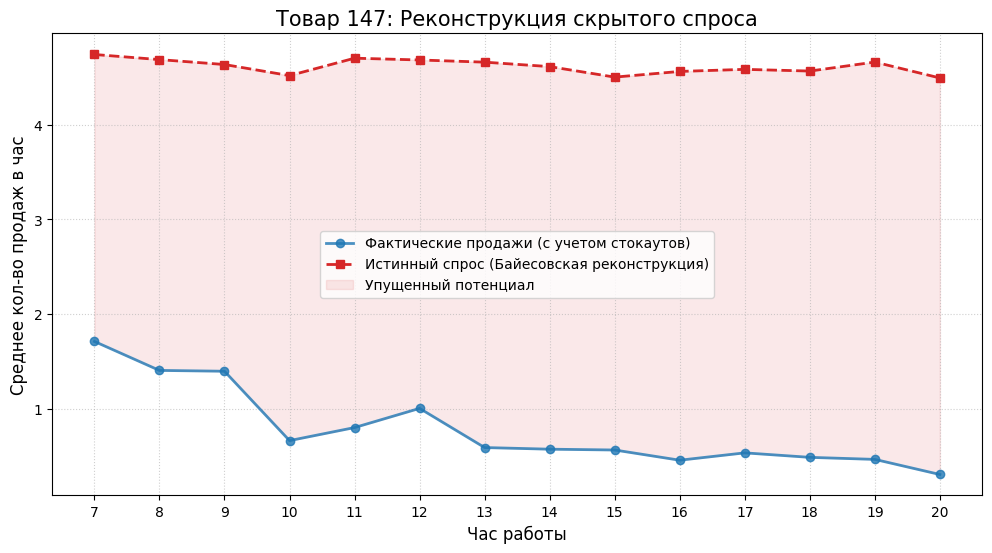

Средние продажи в день: 10.96 шт.
Прогноз 'истинного' спроса: 64.62 шт.
Потенциал роста при устранении стокаутов: 489.5%


In [36]:
import arviz as az
import matplotlib.pyplot as plt

# Извлекаем средние значения lambda для каждого часа из trace
post_mean = az.summary(trace, var_names=["lam"])["mean"].values

# Считаем реальные средние продажи из твоего пивота (для сравнения)
real_mean = df_147_pivot.mean().values

hours = df_147_pivot.columns

plt.figure(figsize=(12, 6))

# Линия реальных продаж
plt.plot(hours, real_mean, label="Фактические продажи (с учетом стокаутов)", 
         color='#1f77b4', marker='o', linewidth=2, alpha=0.8)

# Линия восстановленного спроса
plt.plot(hours, post_mean, label="Истинный спрос (Байесовская реконструкция)", 
         color='#d62728', marker='s', linestyle='--', linewidth=2)

# Подсвечиваем разницу (упущенный спрос)
plt.fill_between(hours, real_mean, post_mean, color='#d62728', alpha=0.1, label="Упущенный потенциал")

plt.title("Товар 147: Реконструкция скрытого спроса", fontsize=15)
plt.xlabel("Час работы", fontsize=12)
plt.ylabel("Среднее кол-во продаж в час", fontsize=12)
plt.xticks(hours)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Выведем сухую цифру
total_real = real_mean.sum()
total_restored = post_mean.sum()
increase = (total_restored / total_real - 1) * 100

print(f"Средние продажи в день: {total_real:.2f} шт.")
print(f"Прогноз 'истинного' спроса: {total_restored:.2f} шт.")
print(f"Потенциал роста при устранении стокаутов: {increase:.1f}%")